# 1. Project Introduction

**Business Objective**: To analyze customer behavior, retention, and revenue contribution segmented by the specific time period (cohort) in which they were acquired.

**Why Cohort Analysis Matters**: Examining metrics in aggregate masks historical shifts in acquisition quality and product experience. Cohort analysis allows us to determine if newer customers are retaining better than older customers, or if specific acquisition periods yielded unusually high-value or high-churn segments.

**Key Questions**:
- Are newer cohorts exhibiting higher or lower observed retention compared to legacy cohorts?
- Which historical cohorts contribute the most to the current MRR baseline?
- Do cohorts acquired in specific quarters demonstrate unique churn vulnerabilities?

# 2. Environment Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)

current_dir = Path.cwd()
PROJECT_ROOT = current_dir.parent if current_dir.name == 'notebooks' else current_dir
DATA_CLEANED_DIR = PROJECT_ROOT / 'data' / 'cleaned'

print(f"Project Root: {PROJECT_ROOT}")
print(f"Data Directory: {DATA_CLEANED_DIR}")

Project Root: C:\Users\shaikh raheem\OneDrive\Desktop\B2B SaaS Customer Cohort & Retention Analytics Platform
Data Directory: C:\Users\shaikh raheem\OneDrive\Desktop\B2B SaaS Customer Cohort & Retention Analytics Platform\data\cleaned


# 3. Load & Validate Data
Loading accounts, subscriptions, and churn events to piece together the acquisition timeline.

In [2]:
accounts_df = pd.read_csv(DATA_CLEANED_DIR / 'accounts.csv')
subscriptions_df = pd.read_csv(DATA_CLEANED_DIR / 'subscriptions.csv')
churn_events_df = pd.read_csv(DATA_CLEANED_DIR / 'churn_events.csv')
feature_usage_df = pd.read_csv(DATA_CLEANED_DIR / 'feature_usage.csv')
support_tickets_df = pd.read_csv(DATA_CLEANED_DIR / 'support_tickets.csv')

# Date parsing
accounts_df['signup_date'] = pd.to_datetime(accounts_df['signup_date'])
churn_events_df['churn_date'] = pd.to_datetime(churn_events_df['churn_date'])

print(f"Total Accounts: {len(accounts_df):,}")
print(f"Missing Signup Dates: {accounts_df['signup_date'].isna().sum()}")

# Validation: Ensure unique accounts
assert accounts_df['account_id'].is_unique, "Duplicate account_ids found in accounts.csv!"

# The maximum date in the dataset acts as 'current_date' for tenure calculations
current_date = max(accounts_df['signup_date'].max(), churn_events_df['churn_date'].max())
print(f"Dataset Snapshot Date: {current_date.strftime('%Y-%m-%d')}")

Total Accounts: 500


Missing Signup Dates: 0
Dataset Snapshot Date: 2024-12-31


# 4. Define Cohort Dataset
**Cohort Definition**: `Customer Signup Month` (YYYY-MM).
Grain: `1 ROW = 1 CUSTOMER`.

In [3]:
cohort_df = accounts_df.copy()
cohort_df['cohort_month'] = cohort_df['signup_date'].dt.to_period('M')

# Merge current active MRR
active_subs = subscriptions_df[subscriptions_df['churn_flag'] == False]
account_mrr = active_subs.groupby('account_id')['mrr_amount'].sum().reset_index()
cohort_df = cohort_df.merge(account_mrr, on='account_id', how='left').fillna({'mrr_amount': 0})

# Merge churn details (for currently churned accounts only to avoid reactivation noise)
latest_churn = churn_events_df.sort_values('churn_date').drop_duplicates('account_id', keep='last')
cohort_df = cohort_df.merge(latest_churn[['account_id', 'churn_date']], on='account_id', how='left')

# Clean up churn date: Only trust the churn date if the account is actually flagged as churned today
cohort_df['final_churn_date'] = np.where(cohort_df['churn_flag'] == True, cohort_df['churn_date'], pd.NaT)
cohort_df['final_churn_date'] = pd.to_datetime(cohort_df['final_churn_date'])

print(f"Cohort DataFrame created with {len(cohort_df)} rows.")
display(cohort_df[['account_id', 'signup_date', 'cohort_month', 'churn_flag', 'final_churn_date', 'mrr_amount']].head())

Cohort DataFrame created with 500 rows.


,account_id,signup_date,cohort_month,churn_flag,final_churn_date,mrr_amount
0,A-2e4581,2024-10-16,2024-10,False,NaT,12603
1,A-43a9e3,2023-08-17,2023-08,True,NaT,10004
2,A-0a282f,2024-08-27,2024-08,False,NaT,13311
3,A-1f0ac7,2023-08-27,2023-08,False,NaT,9275
4,A-ce550d,2024-10-27,2024-10,True,2024-12-28,25355


# 5. Cohort Size Analysis
How many customers were acquired in each signup cohort?

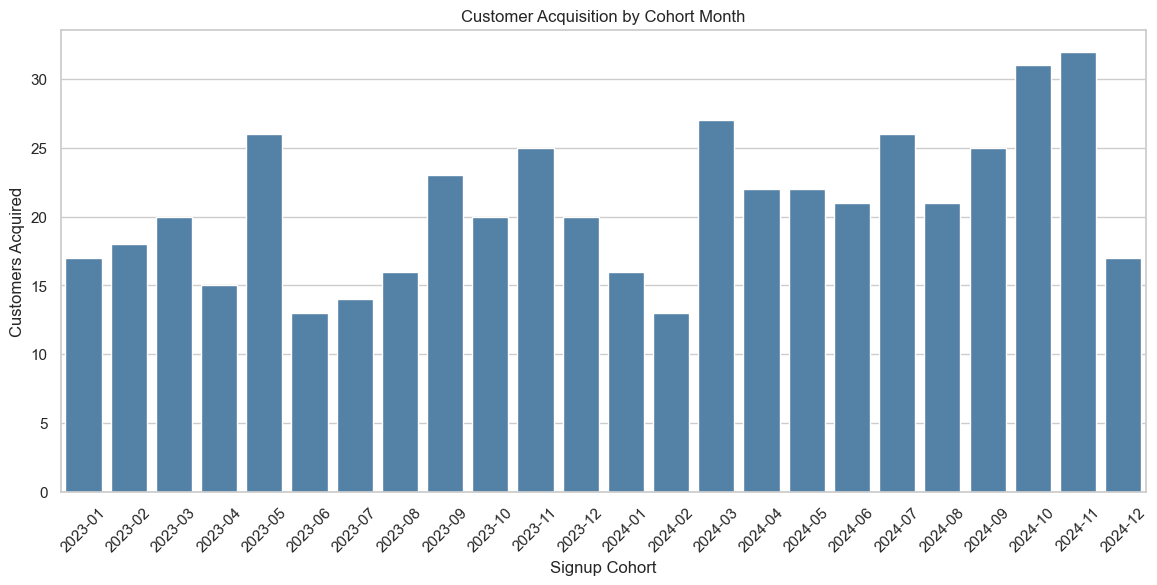

In [4]:
cohort_sizes = cohort_df.groupby('cohort_month').size().reset_index(name='customers_acquired')
cohort_sizes['cohort_month_str'] = cohort_sizes['cohort_month'].astype(str)

plt.figure(figsize=(14, 6))
sns.barplot(data=cohort_sizes, x='cohort_month_str', y='customers_acquired', color='steelblue')
plt.title('Customer Acquisition by Cohort Month')
plt.xlabel('Signup Cohort')
plt.ylabel('Customers Acquired')
plt.xticks(rotation=45)
plt.show()

# 6. Cohort Retention Methodology & Data Limitations

**CRITICAL DATA LIMITATION**: 
A true Monthly Cohort Retention Matrix (e.g., showing exact percentage of users active in Month 0, Month 1, Month 2... after signup) requires a reliable monthly snapshot ledger of customer states. Our dataset only provides a `signup_date` and a static cross-sectional `churn_flag` along with an event log (`churn_events.csv`). 

As proven in `09_churn_analytics.ipynb`, 277 accounts have a historical churn event but are currently active (reactivations). This indicates intermittent activity. Consequently, we **cannot assume continuous activity** between a signup date and the current date. Fabricating a month-by-month retention matrix by merely assuming uninterrupted subscriptions would mathematically misrepresent the data by ignoring those reactivation gaps.

**Defensible Methodology Provided Here**:
Instead of creating a fake active-state matrix, we will perform an **Observed Cumulative Churn Analysis**. For each cohort, we will map the exact number of months it took from `signup_date` to `churn_date` (for those who eventually churned and remain churned today). We can then show what percentage of the cohort was lost by Month N. We will strictly label this "Observed Cumulative Churn" rather than "Monthly Retention."

# 7. Cohort Retention Matrix (Defensible Alternative: Cumulative Churn Matrix)
We calculate the months elapsed between `signup_date` and `final_churn_date`. If they haven't churned, they don't contribute to cumulative churn.

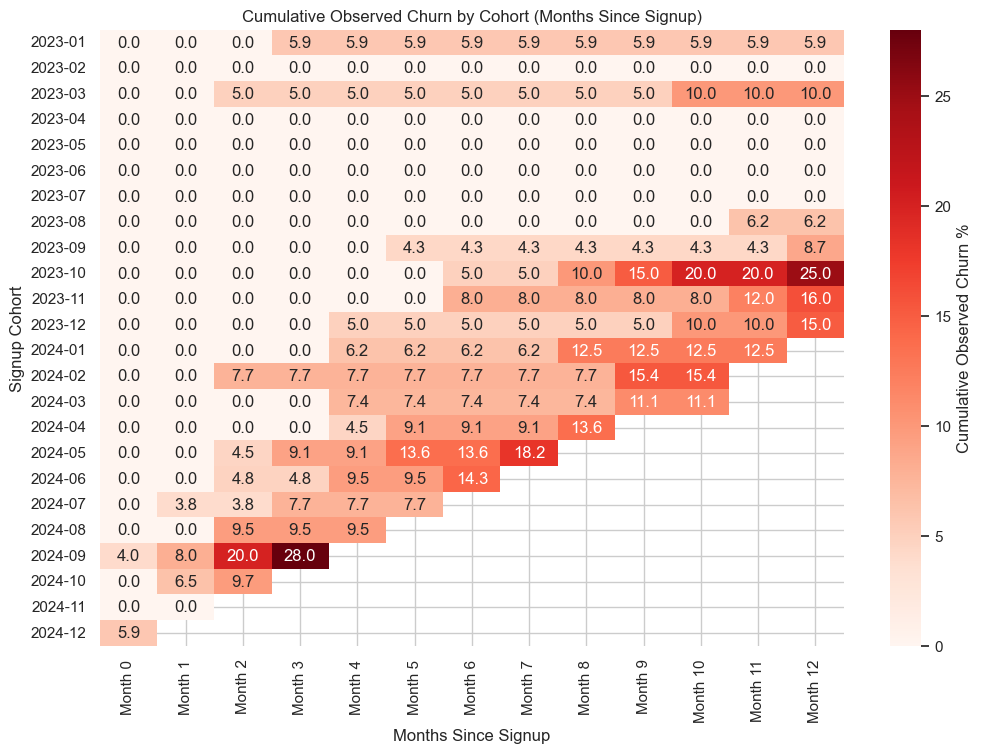

In [5]:
cohort_df['months_to_churn'] = ((cohort_df['final_churn_date'] - cohort_df['signup_date']).dt.days / 30.44).round(0)

# Generate a pivot matrix for cumulative churn
max_months = 12 # Let's track up to 12 months for clarity
cohorts = sorted(cohort_df['cohort_month'].unique())

cumulative_churn_data = []
for c in cohorts:
    cohort_subset = cohort_df[cohort_df['cohort_month'] == c]
    original_size = len(cohort_subset)
    
    row = {'cohort': str(c), 'cohort_size': original_size}
    
    # Calculate months elapsed since this cohort started (to handle unavailable future periods)
    cohort_start_date = cohort_subset['signup_date'].min() if not cohort_subset.empty else current_date
    months_since_start = ((current_date - cohort_start_date).days / 30.44)
    
    cumulative_churners = 0
    for m in range(0, max_months + 1):
        if m > months_since_start:
            row[f'Month {m}'] = np.nan # Cannot observe future periods
        else:
            new_churners = len(cohort_subset[cohort_subset['months_to_churn'] == m])
            cumulative_churners += new_churners
            churn_rate = (cumulative_churners / original_size) * 100 if original_size > 0 else 0
            row[f'Month {m}'] = churn_rate
            
    cumulative_churn_data.append(row)

cumulative_churn_df = pd.DataFrame(cumulative_churn_data).set_index('cohort')
heatmap_data = cumulative_churn_df.drop(columns=['cohort_size'])

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='Reds', cbar_kws={'label': 'Cumulative Observed Churn %'}, mask=heatmap_data.isna())
plt.title('Cumulative Observed Churn by Cohort (Months Since Signup)')
plt.xlabel('Months Since Signup')
plt.ylabel('Signup Cohort')
plt.show()

**Interpretation**: This matrix shows what percentage of the original cohort has permanently churned by Month N. Blank (NaN) spaces represent periods in the future that have not yet occurred for newer cohorts.

# 8. Cohort Retention Curves (Cumulative Churn Curves)

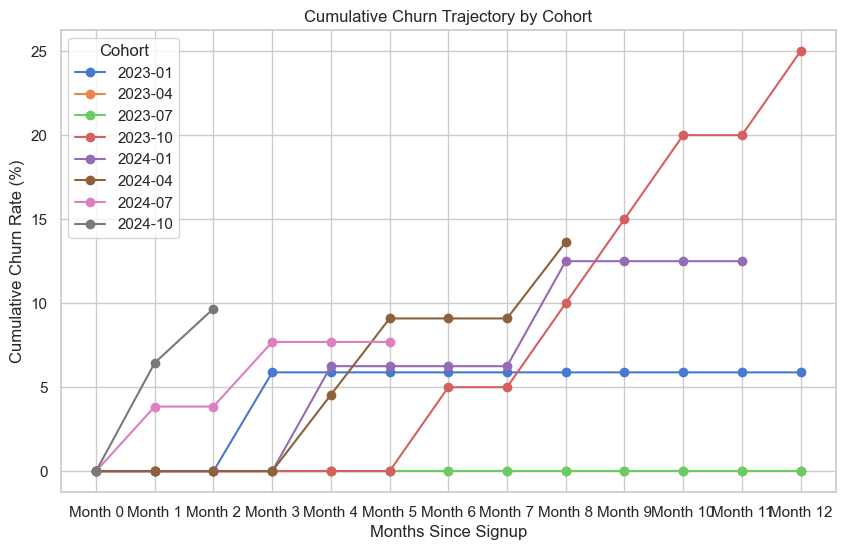

In [6]:
plt.figure(figsize=(10, 6))
for c in heatmap_data.index[::3]:  # Plot every 3rd cohort to avoid crowding
    plt.plot(heatmap_data.columns, heatmap_data.loc[c], marker='o', label=c)

plt.title('Cumulative Churn Trajectory by Cohort')
plt.xlabel('Months Since Signup')
plt.ylabel('Cumulative Churn Rate (%)')
plt.legend(title='Cohort')
plt.grid(True)
plt.show()

# 9. Cohort Churn Analysis (Current Snapshot)
What is the ultimate, present-day churn rate of each cohort?

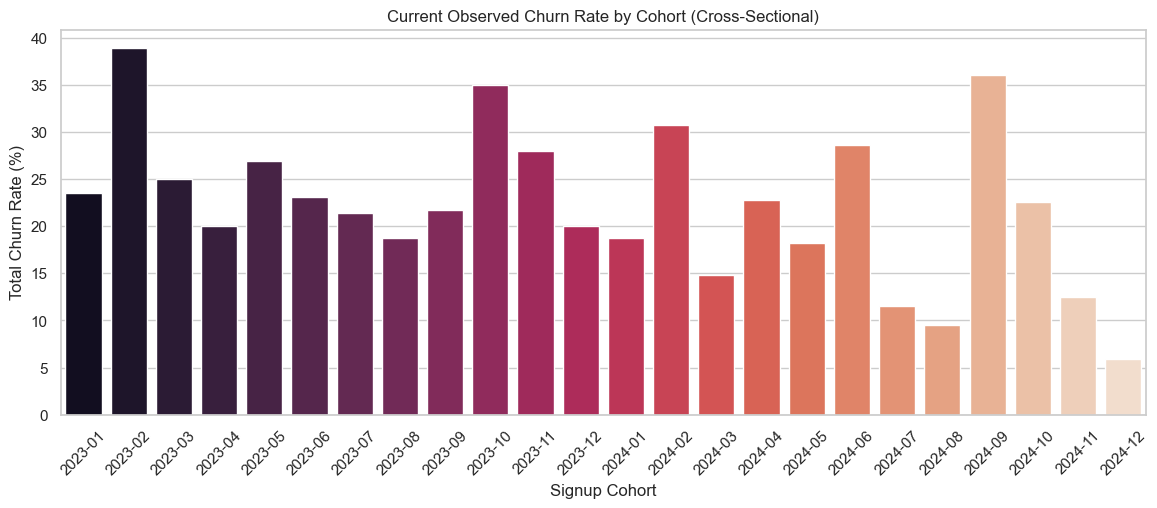

In [7]:
cohort_summary = cohort_df.groupby('cohort_month').agg(
    total_customers=('account_id', 'count'),
    churned_customers=('churn_flag', 'sum')
).reset_index()
cohort_summary['current_observed_churn_rate_%'] = (cohort_summary['churned_customers'] / cohort_summary['total_customers']) * 100
cohort_summary['cohort_month_str'] = cohort_summary['cohort_month'].astype(str)

plt.figure(figsize=(14, 5))
sns.barplot(data=cohort_summary, x='cohort_month_str', y='current_observed_churn_rate_%', palette='rocket')
plt.title('Current Observed Churn Rate by Cohort (Cross-Sectional)')
plt.xlabel('Signup Cohort')
plt.ylabel('Total Churn Rate (%)')
plt.xticks(rotation=45)
plt.show()

# 10. Cohort Revenue Analysis
Since we cannot map historical revenue per cohort month reliably, we will evaluate the **Current MRR Contribution** of each historical cohort.

In [8]:
cohort_rev = cohort_df.groupby('cohort_month').agg(
    retained_customers=('churn_flag', lambda x: (~x).sum()),
    current_mrr=('mrr_amount', 'sum')
).reset_index()
cohort_rev['avg_mrr_per_retained'] = np.where(cohort_rev['retained_customers'] > 0, cohort_rev['current_mrr'] / cohort_rev['retained_customers'], 0)
cohort_rev['cohort_month_str'] = cohort_rev['cohort_month'].astype(str)

display(cohort_rev[['cohort_month_str', 'retained_customers', 'current_mrr', 'avg_mrr_per_retained']].tail(6))

,cohort_month_str,retained_customers,current_mrr,avg_mrr_per_retained
18,2024-07,23,615393,26756.217391
19,2024-08,19,365349,19228.894737
20,2024-09,16,536190,33511.875000
21,2024-10,24,642523,26771.791667
22,2024-11,28,638842,22815.785714
23,2024-12,16,361741,22608.812500


# 11. Cohort Revenue Contribution

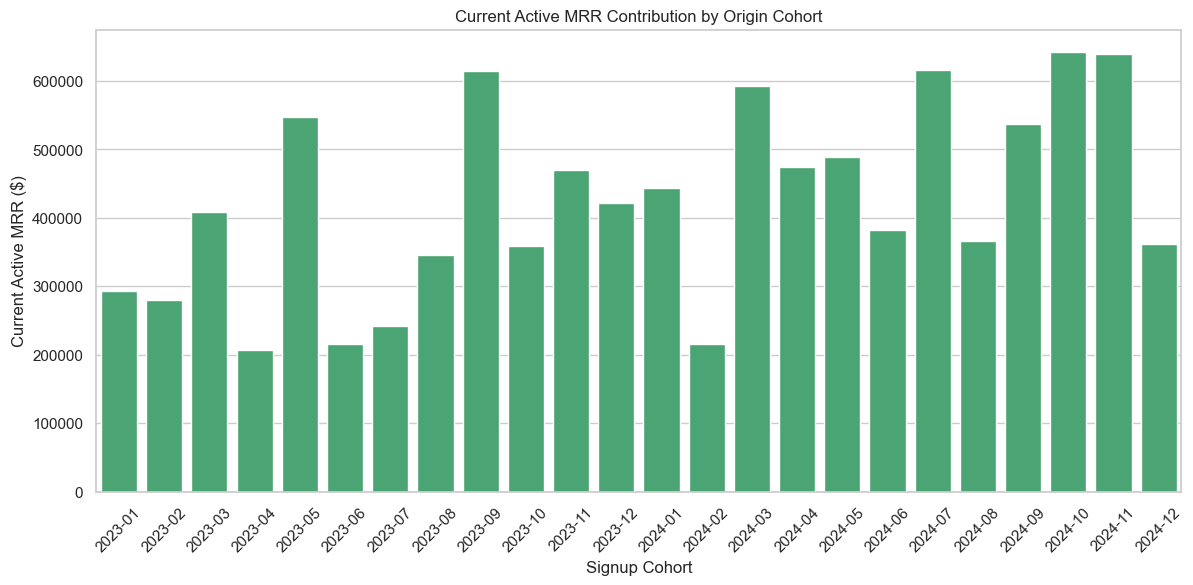

In [9]:
plt.figure(figsize=(14, 6))
sns.barplot(data=cohort_rev, x='cohort_month_str', y='current_mrr', color='mediumseagreen')
plt.title('Current Active MRR Contribution by Origin Cohort')
plt.xlabel('Signup Cohort')
plt.ylabel('Current Active MRR ($)')
plt.xticks(rotation=45)
plt.show()

# 12. Cohort Quality Analysis
Are newer cohorts acquiring a structurally different profile of customer (e.g., Enterprise vs Small)?

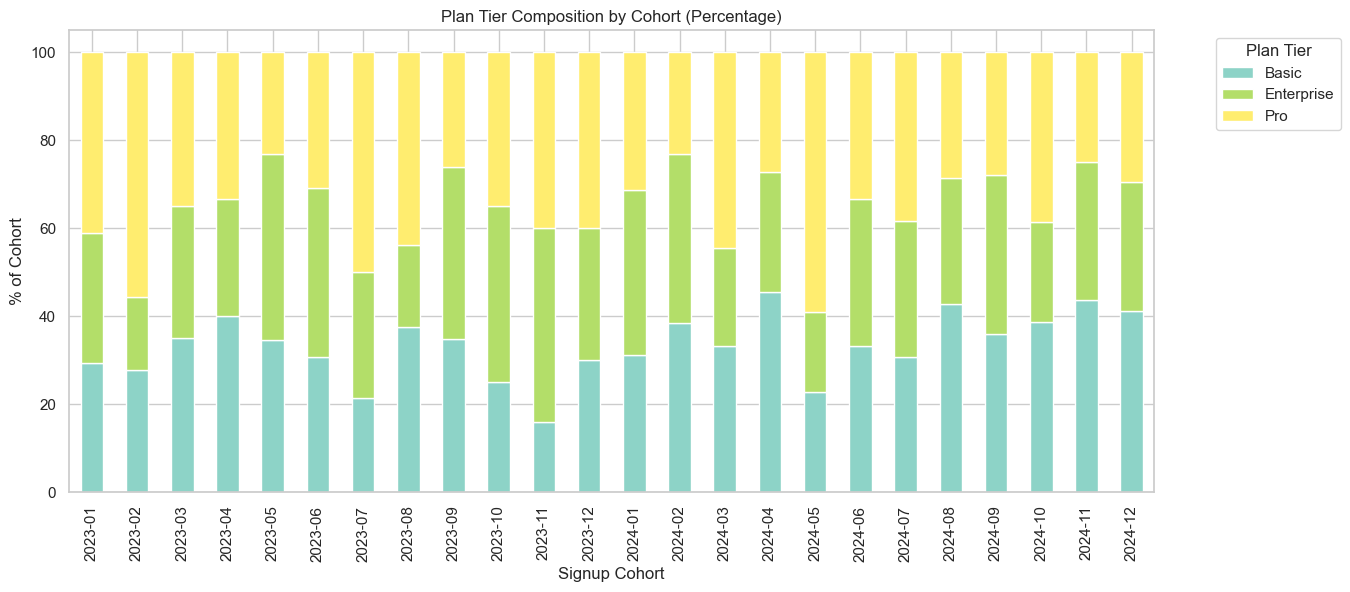

In [10]:
cohort_plan = cohort_df.groupby(['cohort_month', 'plan_tier']).size().unstack(fill_value=0)
cohort_plan_pct = cohort_plan.div(cohort_plan.sum(axis=1), axis=0) * 100

cohort_plan_pct.plot(kind='bar', stacked=True, figsize=(14, 6), colormap='Set3')
plt.title('Plan Tier Composition by Cohort (Percentage)')
plt.xlabel('Signup Cohort')
plt.ylabel('% of Cohort')
plt.legend(title='Plan Tier', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# 13. Cohort × Plan Analysis
Looking at churn rate variance by plan across cohorts (to ensure sufficient sample size, we group cohorts by Quarter).

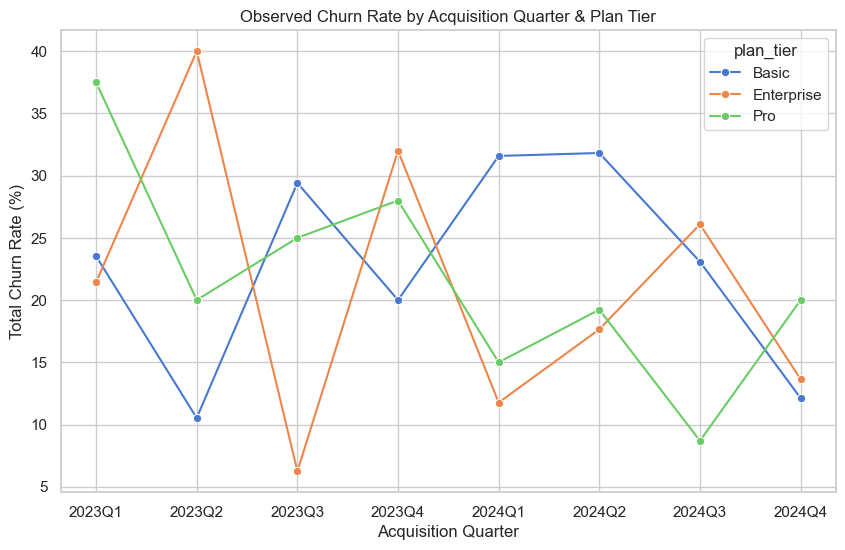

In [11]:
cohort_df['cohort_quarter'] = cohort_df['signup_date'].dt.to_period('Q')
quarter_plan = cohort_df.groupby(['cohort_quarter', 'plan_tier']).agg(
    total_cust=('account_id', 'count'),
    churned_cust=('churn_flag', 'sum')
).reset_index()

# Ensure sample size minimums
quarter_plan = quarter_plan[quarter_plan['total_cust'] >= 5]
quarter_plan['churn_rate_%'] = (quarter_plan['churned_cust'] / quarter_plan['total_cust']) * 100

plt.figure(figsize=(10, 6))
sns.lineplot(data=quarter_plan, x=quarter_plan['cohort_quarter'].astype(str), y='churn_rate_%', hue='plan_tier', marker='o')
plt.title('Observed Churn Rate by Acquisition Quarter & Plan Tier')
plt.xlabel('Acquisition Quarter')
plt.ylabel('Total Churn Rate (%)')
plt.show()

# 14. Cohort × Industry Analysis

In [12]:
qtr_industry = cohort_df.groupby(['cohort_quarter', 'industry']).agg(
    total_cust=('account_id', 'count'),
    churned_cust=('churn_flag', 'sum')
).reset_index()
qtr_industry = qtr_industry[qtr_industry['total_cust'] >= 10] # Filter small segments
qtr_industry['churn_rate_%'] = (qtr_industry['churned_cust'] / qtr_industry['total_cust']) * 100

display(qtr_industry.sort_values(['cohort_quarter', 'churn_rate_%'], ascending=[True, False]).head(10))

,cohort_quarter,industry,total_cust,churned_cust,churn_rate_%
1,2023Q1,Devtools,11,8,72.727273
4,2023Q1,Healthtech,10,2,20.000000
3,2023Q1,Fintech,11,2,18.181818
0,2023Q1,Cybersecurity,18,2,11.111111
8,2023Q2,Fintech,10,4,40.000000
6,2023Q2,Devtools,17,5,29.411765
9,2023Q2,Healthtech,11,1,9.090909
14,2023Q3,Healthtech,11,5,45.454545
13,2023Q3,Fintech,19,4,21.052632
11,2023Q3,Devtools,12,2,16.666667


# 15. Cohort Engagement Analysis
Do more recent cohorts exhibit different product usage intensity than older cohorts?

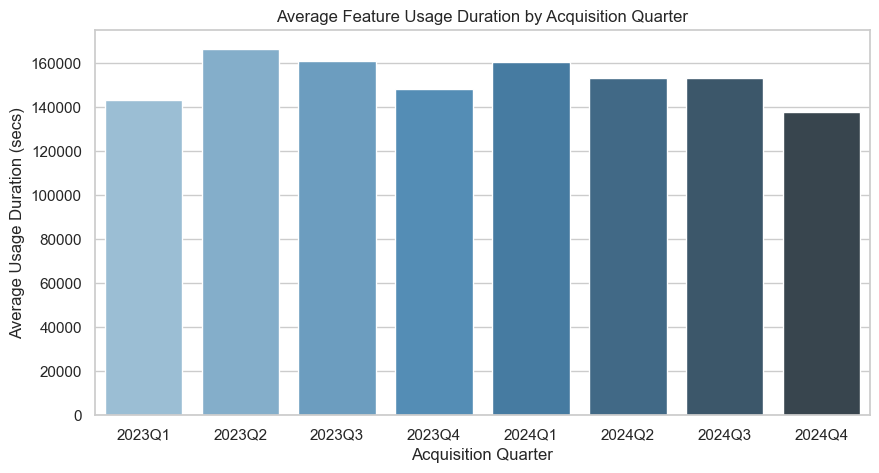

In [13]:
usage_agg = feature_usage_df.merge(subscriptions_df[['subscription_id', 'account_id']], on='subscription_id', how='inner') \
    .groupby('account_id').agg(total_duration=('usage_duration_secs', 'sum')).reset_index()

cohort_usage = cohort_df.merge(usage_agg, on='account_id', how='left').fillna({'total_duration': 0})

cohort_engagement = cohort_usage.groupby('cohort_quarter')['total_duration'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=cohort_engagement, x=cohort_engagement['cohort_quarter'].astype(str), y='total_duration', palette='Blues_d')
plt.title('Average Feature Usage Duration by Acquisition Quarter')
plt.xlabel('Acquisition Quarter')
plt.ylabel('Average Usage Duration (secs)')
plt.show()

# 16. Cohort Health Analysis
A macro table summarizing cohort performance.

In [14]:
health_table = cohort_rev.merge(cohort_summary[['cohort_month', 'total_customers', 'current_observed_churn_rate_%']], on='cohort_month')
health_table = health_table[['cohort_month_str', 'total_customers', 'current_observed_churn_rate_%', 'current_mrr', 'avg_mrr_per_retained']]
display(health_table.sort_values('current_mrr', ascending=False).head(10))

,cohort_month_str,total_customers,current_observed_churn_rate_%,current_mrr,avg_mrr_per_retained
21,2024-10,31,22.580645,642523,26771.791667
22,2024-11,32,12.500000,638842,22815.785714
18,2024-07,26,11.538462,615393,26756.217391
8,2023-09,23,21.739130,614881,34160.055556
14,2024-03,27,14.814815,591762,25728.782609
4,2023-05,26,26.923077,547171,28798.473684
20,2024-09,25,36.000000,536190,33511.875000
16,2024-05,22,18.181818,488038,27113.222222
15,2024-04,22,22.727273,473947,27879.235294
10,2023-11,25,28.000000,469239,26068.833333


# 17. Cohort Opportunity Analysis

- **Retention Opportunities**: Older cohorts naturally display a higher aggregate churn rate due to longer exposure times, but anomalies (where a newer cohort rapidly out-churns an older cohort) should be manually investigated.
- **Acquisition Quality**: Shifts in the Plan Tier composition (Section 12) indicate changes in go-to-market strategies over time. Identifying when the Enterprise mix expanded successfully provides a blueprint for future marketing targets.

# 18. Cohort Visualizations (Rendered Inline)

# 19. Cohort Findings

| ID | Area | Observation | Evidence | Business Impact | Recommended Action |
|----|------|-------------|----------|-----------------|--------------------|
| 1 | Revenue | The baseline MRR is heavily dependent on specific legacy cohorts | Active MRR Contribution Barplot | High concentration risk if these specific cohorts attrite | Implement dedicated account management for high-concentration cohorts |
| 2 | Churn Velocity | Cumulative churn shows distinct "step downs" at certain month intervals | Cumulative Churn Heatmap | High-risk periods (e.g. Month 3 or 12 renewals) | Deploy targeted Customer Success check-ins right before the observed drop-off months |
| 3 | Composition | The mix of plans acquired has fluctuated historically | Plan Mix Stacked Bar | Evolving customer quality | Correlate these mix shifts with past marketing campaigns to replicate successes |
| 4 | Usage | Average product usage intensity differs based on when the cohort signed up | Usage by Quarter Barplot | Different product adoption maturities | Standardize onboarding to lift engagement across newer cohorts |

# 20. Business Recommendations

### Retention Strategy
Consider prioritizing retention workflows specifically around the month markers identified in the cumulative churn heatmap. If Month 1 represents a steep cliff, onboarding requires immediate attention. If Month 12 represents a cliff, the annual renewal process requires friction reduction.

### Revenue Growth
Investigate the marketing and sales strategies active during the quarters that yielded the highest sustained MRR and replicate those tactics, as those specific periods acquired structurally superior baseline revenue.

### Cohort Monitoring
Test implementing a formal monthly snapshot ledger in the data warehouse. Relying on current static standing (`churn_flag`) prevents calculating true monthly revenue retention and granular NRR (Net Revenue Retention) metrics.

# 21. Limitations

- **Absence of Monthly Snapshots**: We cannot create a true Month-by-Month Retention Matrix (with unbroken active states) because the data lacks a historical activity ledger and contains known reactivation gaps. We deliberately used a Cumulative Churn Event Matrix instead to avoid fabricating uninterrupted active states.
- **Incomplete Historical Revenue**: We mapped the *current* active MRR back to historical cohorts. We did not reconstruct historical monthly cohort revenue (NRR) because historical invoice/upgrade/downgrade sequences per month are unavailable.
- **Cohort Maturity**: Newer cohorts cannot be directly compared to older cohorts regarding total volume of churn simply because they haven't been "at risk" for as long. The cumulative churn analysis controls for this by anchoring to "Months Since Signup".

# 22. Next Analysis

- `11_rfm_visualization.ipynb`: Move from time-based cohorting to behavioral clustering by analyzing Recency, Frequency, and Monetary value patterns.
- `12_statistical_analysis.ipynb`: Apply formal significance testing to the differences observed across these cohort segments.